# BNPL Delinquency Risk Model: Technical Walkthrough

Full modeling pipeline: EDA, feature engineering, a temporal train/val/test split, a time-series cross-validated hyperparameter search, a logistic regression baseline vs. gradient-boosted trees, probability calibration, a cost-based decision threshold, SHAP interpretability, and a drift-monitoring check against a simulated macro shock.

For the short, stakeholder-facing version of this project see the [project README](../README.md).

All data here is synthetic, generated by `src/generate_data.py`. No proprietary data, models, or results from any employer are used or implied.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve, confusion_matrix,
)
import shap

from style import set_style, style_ax, savefig, add_footnote, SLATE, MUTED_TEAL, MUTED_RED, GREY, PALETTE
from features import engineer_features, build_design_matrix

set_style()
pd.set_option("display.max_columns", 50)
%matplotlib inline

## 1. Data

18k synthetic BNPL loans from 9k customers over a 24-month window. Customer demographics, a bureau-style credit score, prior repayment behavior, and loan terms. The target is `delinquent_30dpd`: whether the loan went 30+ days past due.

In [2]:
df = pd.read_csv("../data/loans.csv")
SOURCE_FULL = f"Source: synthetic BNPL loan data (src/generate_data.py) · n = {len(df):,} loans"
print(f"{len(df):,} loans, {df['customer_id'].nunique():,} customers")
print(f"Overall delinquency rate: {df['delinquent_30dpd'].mean():.2%}")
df.head()

18,092 loans, 9,144 customers
Overall delinquency rate: 14.23%


,loan_id,customer_id,origination_month,merchant_category,num_installments,loan_amount_mxn,down_payment_ratio,age,city,city_tier,employment_type,monthly_income_mxn,tenure_months_platform,num_previous_loans,credit_bureau_score,avg_prior_repayment_delay_days,num_active_loans_elsewhere,device_type,acquisition_channel,delinquent_30dpd
0,2797,1849,21,fashion,9,1366.31,0.348,39,Leon,tier2,salaried,5724.45,39,5,436,2.5,0,ios,partner_store,0
1,10228,6851,24,fashion,6,1139.68,0.151,45,Guadalajara,tier1,self_employed,5136.39,29,6,397,0.0,1,android,organic,0
2,7771,5164,9,fashion,9,1396.21,0.260,30,Leon,tier2,salaried,4240.10,40,6,499,2.5,1,android,partner_store,0
3,3288,2178,20,home_goods,3,2644.57,0.026,40,Monterrey,tier1,gig_economy,9798.31,22,3,508,9.0,1,android,partner_store,0
4,5860,3885,23,electronics,9,2187.33,0.460,57,Guadalajara,tier1,salaried,13972.35,38,10,561,0.0,1,web,organic,0


## 2. Exploratory analysis

The last 3 months carry a synthetic macro shock (an inflation/rate spike) that raises delinquency without changing the input feature distributions. That gap is the basis for the drift-monitoring section at the end.

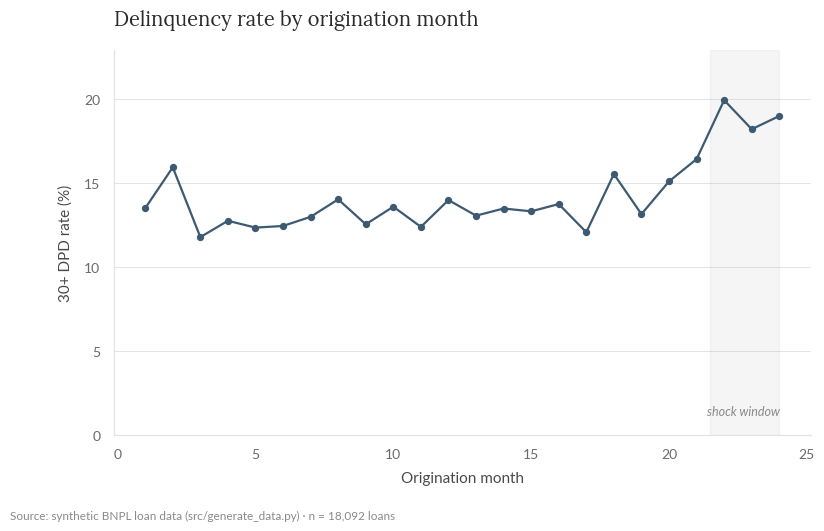

In [3]:
by_month = df.groupby("origination_month")["delinquent_30dpd"].mean()
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(by_month.index, by_month.values * 100, color=SLATE, linewidth=1.6)
ax.scatter(by_month.index, by_month.values * 100, color=SLATE, s=18, zorder=3)
ax.axvspan(21.5, 24, color=GREY, alpha=0.08)
ax.text(22.7, 1.2, "shock window", fontsize=9, color=GREY, ha="center", style="italic")
style_ax(ax, title="Delinquency rate by origination month",
         xlabel="Origination month", ylabel="30+ DPD rate (%)")
ax.set_ylim(0, by_month.values.max() * 100 * 1.15)
add_footnote(fig, SOURCE_FULL)
plt.show()

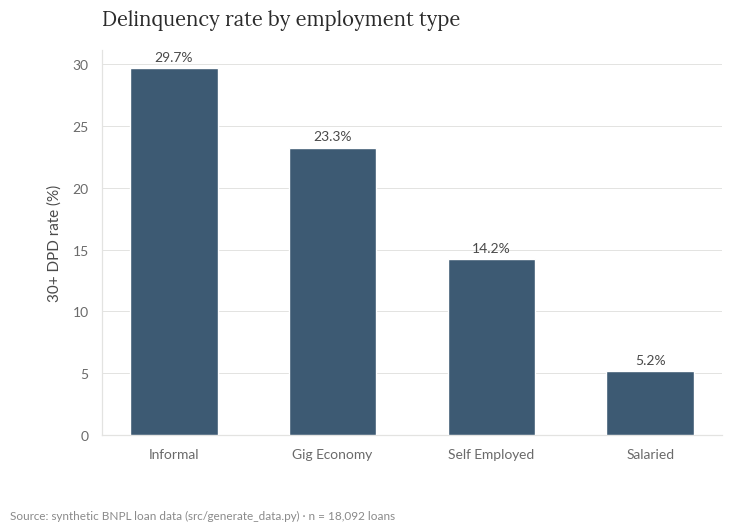

In [4]:
order = df.groupby("employment_type")["delinquent_30dpd"].mean().sort_values(ascending=False).index
rates = df.groupby("employment_type")["delinquent_30dpd"].mean().reindex(order) * 100
labels = [o.replace("_", " ").title() for o in order]
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(labels, rates.values, color=SLATE, width=0.55, zorder=3)
for i, v in enumerate(rates.values):
    ax.text(i, v + 0.6, f"{v:.1f}%", ha="center", fontsize=10, color="#4a4a4a")
style_ax(ax, title="Delinquency rate by employment type", ylabel="30+ DPD rate (%)")
add_footnote(fig, SOURCE_FULL)
plt.show()

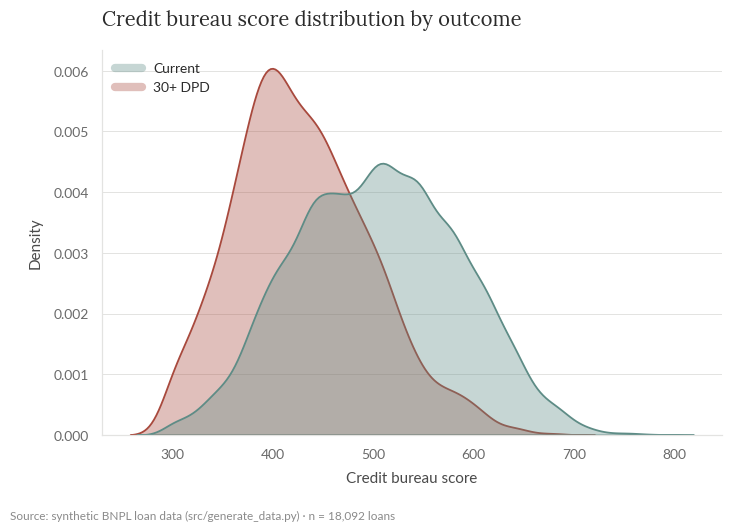

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(data=df, x="credit_bureau_score", hue="delinquent_30dpd", fill=True,
            common_norm=False, palette=[MUTED_TEAL, MUTED_RED], alpha=0.35, linewidth=1.3, ax=ax, legend=False)
ax.plot([], [], color=MUTED_TEAL, linewidth=6, alpha=0.35, label="Current")
ax.plot([], [], color=MUTED_RED, linewidth=6, alpha=0.35, label="30+ DPD")
ax.legend(loc="upper left")
style_ax(ax, title="Credit bureau score distribution by outcome",
         xlabel="Credit bureau score", ylabel="Density")
add_footnote(fig, SOURCE_FULL)
plt.show()

Bureau score, employment type, and the month-22-24 shock all show clear separation. Next: turn the raw loan/customer columns into a model-ready feature set.

## 3. Feature engineering

`engineer_features` adds ratios (loan-to-income, installment-to-income), thin-file/new-customer flags, and leaves categoricals for one-hot encoding in `build_design_matrix`.

In [6]:
df = engineer_features(df)
X_all, feature_names = build_design_matrix(df)
print(f"{X_all.shape[1]} features after encoding")
X_all.head()

35 features after encoding


,age,monthly_income_mxn,tenure_months_platform,num_previous_loans,credit_bureau_score,avg_prior_repayment_delay_days,num_active_loans_elsewhere,num_installments,loan_amount_mxn,down_payment_ratio,loan_to_income_ratio,installment_amount_mxn,installment_to_income_ratio,low_bureau_score,is_new_customer,city_tier_tier1,city_tier_tier2,city_tier_tier3,employment_type_gig_economy,employment_type_informal,employment_type_salaried,employment_type_self_employed,device_type_android,device_type_ios,device_type_web,acquisition_channel_organic,acquisition_channel_paid_social,acquisition_channel_partner_store,acquisition_channel_referral,merchant_category_education,merchant_category_electronics,merchant_category_fashion,merchant_category_groceries,merchant_category_home_goods,merchant_category_travel
0,39,5724.45,39,5,436,2.5,0,9,1366.31,0.348,0.238680,98.981569,0.017291,1,0,False,True,False,False,False,True,False,False,True,False,False,False,True,False,False,False,True,False,False,False
1,45,5136.39,29,6,397,0.0,1,6,1139.68,0.151,0.221883,161.264720,0.031397,1,0,True,False,False,False,False,False,True,True,False,False,True,False,False,False,False,False,True,False,False,False
2,30,4240.10,40,6,499,2.5,1,9,1396.21,0.260,0.329287,114.799489,0.027075,1,0,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,True,False,False,False
3,40,9798.31,22,3,508,9.0,1,3,2644.57,0.026,0.269901,858.603727,0.087628,1,0,True,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False
4,57,13972.35,38,10,561,0.0,1,9,2187.33,0.460,0.156547,131.239800,0.009393,1,0,True,False,False,False,False,True,False,False,False,True,True,False,False,False,False,True,False,False,False,False


## 4. Temporal train / validation / test split

No random shuffling: a real deployment never sees the future at train time. Train on months 1-18, calibrate probabilities on 19-21, evaluate on 22-24 (which includes the shock, so the test set also doubles as the "monitored" window later on).

In [7]:
train_df = df[df.origination_month <= 18]
val_df = df[(df.origination_month > 18) & (df.origination_month <= 21)]
test_df = df[df.origination_month > 21]

X_train, y_train = X_all.loc[train_df.index], train_df["delinquent_30dpd"].values
X_val, y_val = X_all.loc[val_df.index], val_df["delinquent_30dpd"].values
X_test, y_test = X_all.loc[test_df.index], test_df["delinquent_30dpd"].values

SOURCE_TEST = f"Source: synthetic BNPL loan data · held-out test set, months 22-24 · n = {len(test_df):,} loans"
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

Train: 13,499 | Val: 2,347 | Test: 2,246


## 5. Hyperparameter search (time-series cross-validation)

Hand-picked hyperparameters aren't a great look, and neither is validating on a single chronological split alone, since the reported AUC could just be a lucky or unlucky draw for that particular window. `TimeSeriesSplit` fits on an expanding window of months and validates on the months right after it, several times over, so the search picks hyperparameters that hold up across time rather than to one snapshot. The search only touches months 1-18 (the train region); the calibration window (19-21) and the true held-out test (22-24, with the shock) are never touched here.

In [8]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

train_sorted = train_df.sort_values("origination_month")
X_train_sorted = X_all.loc[train_sorted.index]
y_train_sorted = train_sorted["delinquent_30dpd"].values

param_distributions = {
    "max_depth": [3, 4, 5, 6, 7, None],
    "learning_rate": uniform(0.02, 0.18),
    "max_iter": randint(100, 500),
    "l2_regularization": uniform(0.0, 2.0),
    "max_leaf_nodes": [15, 31, 63, 127, None],
    "min_samples_leaf": randint(10, 60),
}

tscv = TimeSeriesSplit(n_splits=5)
search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=42, class_weight="balanced"),
    param_distributions, n_iter=30, scoring="roc_auc", cv=tscv, random_state=42, n_jobs=-1, refit=False,
)
search.fit(X_train_sorted, y_train_sorted)

cv_results = pd.DataFrame(search.cv_results_).sort_values("mean_test_score", ascending=False).reset_index(drop=True)
best_row = cv_results.iloc[0]
best_params = {k.replace("param_", ""): (v.item() if hasattr(v, "item") else v)
               for k, v in best_row.items() if k.startswith("param_")}

print(f"Best CV AUC: {best_row['mean_test_score']:.4f} +/- {best_row['std_test_score']:.4f}")
print("Best params:", best_params)

Best CV AUC: 0.8127 +/- 0.0038
Best params: {'l2_regularization': 0.014132610439434812, 'learning_rate': 0.024151236507454835, 'max_depth': 5, 'max_iter': 158, 'max_leaf_nodes': 31, 'min_samples_leaf': 37}


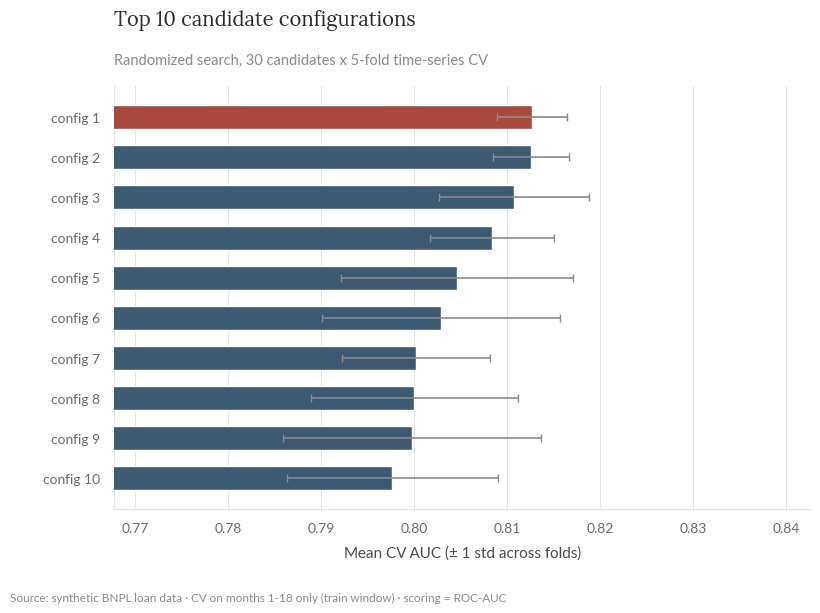

In [9]:
top10 = cv_results.head(10)
fig, ax = plt.subplots(figsize=(9, 5.5))
y_pos = np.arange(len(top10))[::-1]
colors = [MUTED_RED if i == 0 else SLATE for i in range(len(top10))]
ax.barh(y_pos, top10["mean_test_score"], xerr=top10["std_test_score"],
        color=colors, height=0.6, zorder=3, error_kw={"ecolor": GREY, "elinewidth": 1.2, "capsize": 3})
ax.set_yticks(y_pos)
ax.set_yticklabels([f"config {i+1}" for i in range(len(top10))])
ax.set_xlim(top10["mean_test_score"].min() - 0.03, top10["mean_test_score"].max() + 0.03)
style_ax(ax, title="Top 10 candidate configurations",
         subtitle="Randomized search, 30 candidates x 5-fold time-series CV",
         xlabel="Mean CV AUC (± 1 std across folds)", grid_axis="x")
add_footnote(fig, "Source: synthetic BNPL loan data · CV on months 1-18 only (train window) · scoring = ROC-AUC")
plt.show()

The gap between the top configs is small, mostly within one standard deviation of each other. That's useful information on its own: this model isn't hypersensitive to the exact hyperparameter choice, which is a healthier finding than a search that swings wildly between configs.

## 6. Modeling: logistic regression baseline vs. gradient-boosted trees

A regularized linear model as an interpretable benchmark, and `HistGradientBoostingClassifier`, using the tuned hyperparameters from the search above, as the main candidate.

In [10]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

logit = LogisticRegression(max_iter=2000, class_weight="balanced")
logit.fit(X_train_s, y_train)
logit_auc = roc_auc_score(y_test, logit.predict_proba(X_test_s)[:, 1])

gbm = HistGradientBoostingClassifier(
    **best_params, random_state=42, class_weight="balanced",
)
gbm.fit(X_train, y_train)
gbm_auc_raw = roc_auc_score(y_test, gbm.predict_proba(X_test)[:, 1])

print(f"Logistic regression AUC: {logit_auc:.3f}")
print(f"Gradient boosted trees AUC (raw): {gbm_auc_raw:.3f}")

Logistic regression AUC: 0.804
Gradient boosted trees AUC (raw): 0.791


The two are close. The underlying drivers here are close to additive, so a well-regularized linear model captures most of the signal. That's worth checking directly rather than assuming the more complex model wins by default.

## 7. Probability calibration

Raw GBM probabilities from tree ensembles tend to be overconfident. Isotonic calibration, fit on the untouched validation window (months 19-21), fixes this before any threshold or cost decision is made.

Brier score, raw: 0.1696 -> calibrated: 0.1269


/sessions/bold-sleepy-meitner/.local/lib/python3.10/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


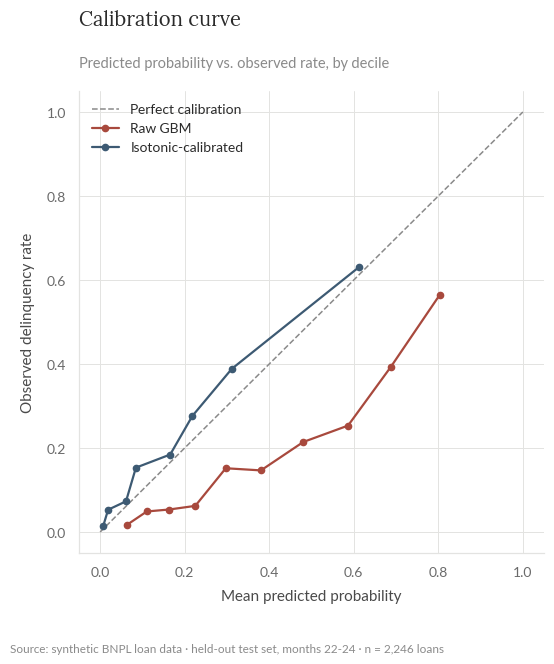

In [11]:
calibrated = CalibratedClassifierCV(gbm, method="isotonic", cv="prefit")
calibrated.fit(X_val, y_val)

y_prob_raw = gbm.predict_proba(X_test)[:, 1]
y_prob_test = calibrated.predict_proba(X_test)[:, 1]

brier_raw = brier_score_loss(y_test, y_prob_raw)
brier_cal = brier_score_loss(y_test, y_prob_test)
print(f"Brier score, raw: {brier_raw:.4f} -> calibrated: {brier_cal:.4f}")

frac_pos_raw, mean_pred_raw = calibration_curve(y_test, y_prob_raw, n_bins=10, strategy="quantile")
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, y_prob_test, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "--", color=GREY, linewidth=1.1, label="Perfect calibration")
ax.plot(mean_pred_raw, frac_pos_raw, marker="o", markersize=4.5, color=MUTED_RED, linewidth=1.6, label="Raw GBM")
ax.plot(mean_pred_cal, frac_pos_cal, marker="o", markersize=4.5, color=SLATE, linewidth=1.6, label="Isotonic-calibrated")
style_ax(ax, title="Calibration curve",
         subtitle="Predicted probability vs. observed rate, by decile",
         xlabel="Mean predicted probability", ylabel="Observed delinquency rate", grid_axis="both")
ax.legend(loc="upper left")
add_footnote(fig, SOURCE_TEST)
plt.show()

## 8. Cost-based decision threshold

A missed delinquent loan (false negative) costs roughly 70% of principal net of recoveries; declining a good customer (false positive) forgoes about a 6% fee margin. Sweeping the threshold against these costs, instead of defaulting to 0.5, is what actually moves the P&L.

Cost-optimal threshold: 0.06
Expected cost at optimal threshold: $154,799
Expected cost at naive t=0.50: $458,285  (66.2% higher)


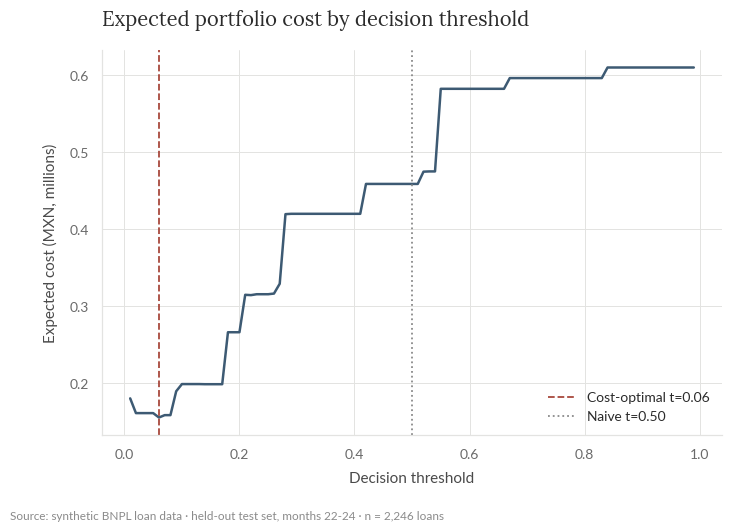

In [12]:
COST_FN_RATE = 0.70   # approved a loan that went delinquent
COST_FP_RATE = 0.06   # declined a loan that would have been repaid

loan_amounts = test_df["loan_amount_mxn"].values
thresholds = np.linspace(0.01, 0.99, 99)
costs = []
for t in thresholds:
    pred = (y_prob_test >= t).astype(int)
    fn_mask = (pred == 0) & (y_test == 1)
    fp_mask = (pred == 1) & (y_test == 0)
    cost = (loan_amounts[fn_mask] * COST_FN_RATE).sum() + (loan_amounts[fp_mask] * COST_FP_RATE).sum()
    costs.append(cost)
costs = np.array(costs)
best_t = thresholds[costs.argmin()]
default_cost = costs[np.argmin(np.abs(thresholds - 0.5))]
best_cost = costs.min()

print(f"Cost-optimal threshold: {best_t:.2f}")
print(f"Expected cost at optimal threshold: ${best_cost:,.0f}")
print(f"Expected cost at naive t=0.50: ${default_cost:,.0f}  ({(1 - best_cost/default_cost):.1%} higher)")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, costs / 1e6, color=SLATE, linewidth=1.8)
ax.axvline(best_t, ls="--", color=MUTED_RED, linewidth=1.3, label=f"Cost-optimal t={best_t:.2f}")
ax.axvline(0.50, ls=":", color=GREY, linewidth=1.3, label="Naive t=0.50")
style_ax(ax, title="Expected portfolio cost by decision threshold",
         xlabel="Decision threshold", ylabel="Expected cost (MXN, millions)", grid_axis="both")
ax.legend()
add_footnote(fig, SOURCE_TEST)
plt.show()

The optimal threshold sits far below 0.5: a missed delinquent loan costs about 12x more than declining a good customer, so the model should approve conservatively even at the expense of precision.

## 9. Held-out performance at the chosen threshold

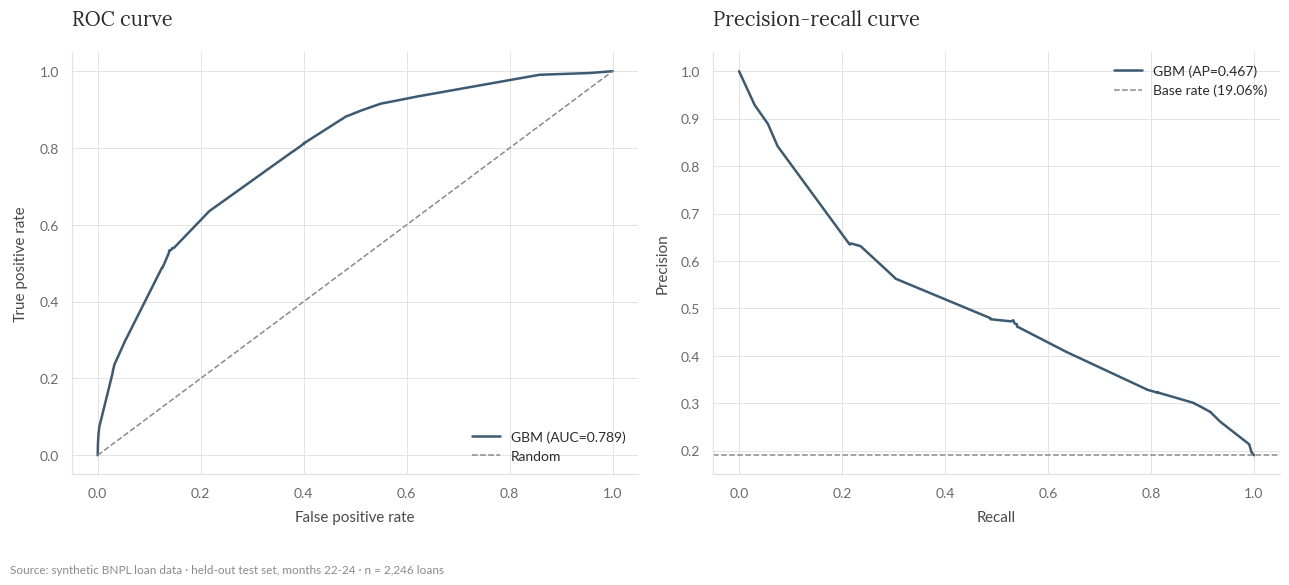

In [13]:
auc = roc_auc_score(y_test, y_prob_test)
ap = average_precision_score(y_test, y_prob_test)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
prec, rec, _ = precision_recall_curve(y_test, y_prob_test)
base_rate = y_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
axes[0].plot(fpr, tpr, color=SLATE, linewidth=1.8, label=f"GBM (AUC={auc:.3f})")
axes[0].plot([0, 1], [0, 1], "--", color=GREY, linewidth=1.1, label="Random")
style_ax(axes[0], title="ROC curve", xlabel="False positive rate", ylabel="True positive rate", grid_axis="both")
axes[0].legend(loc="lower right")

axes[1].plot(rec, prec, color=SLATE, linewidth=1.8, label=f"GBM (AP={ap:.3f})")
axes[1].axhline(base_rate, ls="--", color=GREY, linewidth=1.1, label=f"Base rate ({base_rate:.2%})")
style_ax(axes[1], title="Precision-recall curve", xlabel="Recall", ylabel="Precision", grid_axis="both")
axes[1].legend(loc="upper right")
plt.tight_layout()
add_footnote(fig, SOURCE_TEST)
plt.show()

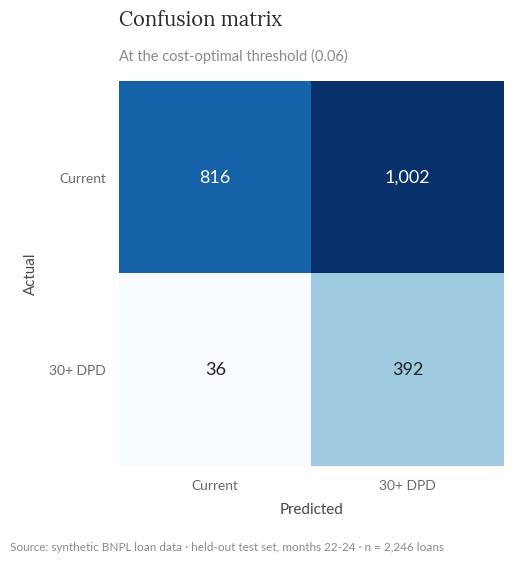

Precision: 0.281 | Recall: 0.916


In [14]:
y_pred_best = (y_prob_test >= best_t).astype(int)
cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp)
recall = tp / (tp + fn)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Current", "30+ DPD"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Current", "30+ DPD"])
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
style_ax(ax, title="Confusion matrix",
         subtitle=f"At the cost-optimal threshold ({best_t:.2f})", xlabel="Predicted", ylabel="Actual", grid_axis=None)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=13,
                 color="white" if cm[i, j] > cm.max() / 2 else "#222222")
add_footnote(fig, SOURCE_TEST)
plt.show()

print(f"Precision: {precision:.3f} | Recall: {recall:.3f}")

In [15]:
pd.DataFrame({
    "Metric": ["Logistic regression AUC", "GBM AUC", "GBM PR-AUC (AP)",
               "Brier (raw)", "Brier (calibrated)", "Cost-optimal threshold",
               "Precision @ threshold", "Recall @ threshold", "Cost reduction vs. naive t=0.5"],
    "Value": [f"{logit_auc:.3f}", f"{auc:.3f}", f"{ap:.3f}", f"{brier_raw:.4f}", f"{brier_cal:.4f}",
              f"{best_t:.2f}", f"{precision:.3f}", f"{recall:.3f}",
              f"{(1 - best_cost/default_cost):.1%}"],
})

,Metric,Value
0,Logistic regression AUC,0.804
1,GBM AUC,0.789
2,GBM PR-AUC (AP),0.467
3,Brier (raw),0.1696
4,Brier (calibrated),0.1269
5,Cost-optimal threshold,0.06
6,Precision @ threshold,0.281
7,Recall @ threshold,0.916
8,Cost reduction vs. naive t=0.5,66.2%


## 10. Interpretability (SHAP)

Tree SHAP values on the held-out set, to check the model is picking up sensible, defensible drivers rather than noise.

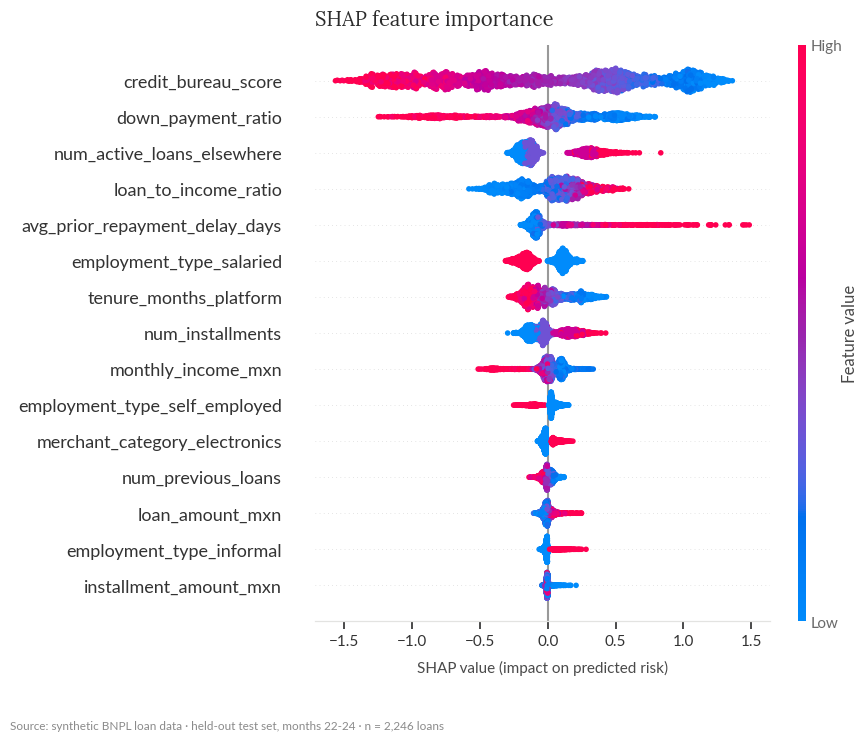

In [16]:
explainer = shap.TreeExplainer(gbm)
shap_values = explainer(X_test)

fig = plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values, X_test, show=False, max_display=15, plot_size=None)
ax = plt.gca()
ax.set_title("SHAP feature importance", loc="left", fontsize=14.5, fontweight="normal",
             fontfamily="Lora", color="#2B2B2B", pad=14)
ax.set_xlabel("SHAP value (impact on predicted risk)", fontsize=11, labelpad=8)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
add_footnote(fig, SOURCE_TEST)
plt.tight_layout()
plt.show()

Bureau score, down payment ratio, existing loans elsewhere, and loan-to-income ratio dominate, consistent with the EDA and with standard credit-risk intuition.

## 11. Monitoring: drift after the macro shock

Comparing the training population (months 1-21) against the shocked window (22-24, held out from training). Two checks: input feature drift (PSI) and outcome/calibration drift.

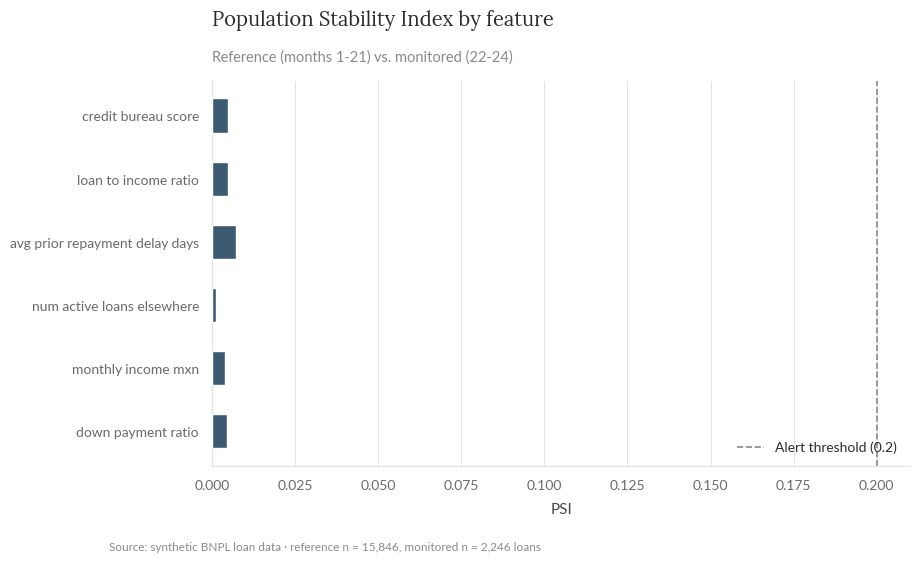

{'credit_bureau_score': 0.0046, 'loan_to_income_ratio': 0.0047, 'avg_prior_repayment_delay_days': 0.0072, 'num_active_loans_elsewhere': 0.001, 'monthly_income_mxn': 0.0038, 'down_payment_ratio': 0.0043}


In [17]:
def psi(reference, current, bins=10):
    cut_points = np.unique(np.quantile(reference, np.linspace(0, 1, bins + 1)))
    if len(cut_points) < 3:
        return 0.0
    ref_counts, _ = np.histogram(reference, bins=cut_points)
    cur_counts, _ = np.histogram(current, bins=cut_points)
    ref_pct = np.clip(ref_counts / max(ref_counts.sum(), 1), 1e-4, None)
    cur_pct = np.clip(cur_counts / max(cur_counts.sum(), 1), 1e-4, None)
    return float(np.sum((cur_pct - ref_pct) * np.log(cur_pct / ref_pct)))

reference = df[df.origination_month <= 21]
monitored = df[df.origination_month > 21]
SOURCE_DRIFT = f"Source: synthetic BNPL loan data · reference n = {len(reference):,}, monitored n = {len(monitored):,} loans"
MONITORED_FEATURES = ["credit_bureau_score", "loan_to_income_ratio", "avg_prior_repayment_delay_days",
                       "num_active_loans_elsewhere", "monthly_income_mxn", "down_payment_ratio"]
PSI_ALERT = 0.20

psi_results = {f: round(psi(reference[f].values, monitored[f].values), 4) for f in MONITORED_FEATURES}

fig, ax = plt.subplots(figsize=(9, 5))
feats = [f.replace("_", " ") for f in psi_results.keys()]
vals = list(psi_results.values())
colors = [MUTED_RED if v > PSI_ALERT else SLATE for v in vals]
ax.barh(feats, vals, color=colors, zorder=3, height=0.55)
ax.axvline(PSI_ALERT, ls="--", color=GREY, linewidth=1.2, label=f"Alert threshold ({PSI_ALERT})")
ax.invert_yaxis()
style_ax(ax, title="Population Stability Index by feature",
         subtitle="Reference (months 1-21) vs. monitored (22-24)",
         xlabel="PSI", grid_axis="x")
ax.legend(loc="lower right")
add_footnote(fig, SOURCE_DRIFT)
plt.show()

print(psi_results)

Mean predicted probability (monitored window): 15.43%
Observed delinquency rate (monitored window): 19.06%
Calibration gap: 3.63%


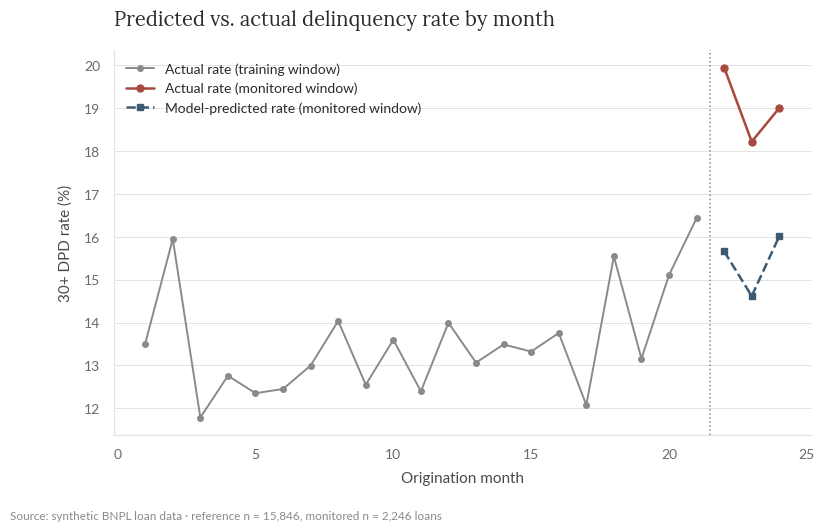

In [18]:
X_monitored = X_all.loc[monitored.index]
y_monitored = monitored["delinquent_30dpd"].values
y_prob_monitored = calibrated.predict_proba(X_monitored)[:, 1]

mean_pred = y_prob_monitored.mean()
observed_rate = y_monitored.mean()
print(f"Mean predicted probability (monitored window): {mean_pred:.2%}")
print(f"Observed delinquency rate (monitored window): {observed_rate:.2%}")
print(f"Calibration gap: {observed_rate - mean_pred:.2%}")

monitored_scored = monitored.copy()
monitored_scored["pred_prob"] = y_prob_monitored
by_month_m = monitored_scored.groupby("origination_month").agg(
    actual_rate=("delinquent_30dpd", "mean"), predicted_rate=("pred_prob", "mean"))
ref_by_month = reference.groupby("origination_month")["delinquent_30dpd"].mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ref_by_month.index, ref_by_month.values * 100, marker="o", markersize=4, color=GREY, linewidth=1.4,
        label="Actual rate (training window)")
ax.plot(by_month_m.index, by_month_m["actual_rate"] * 100, marker="o", markersize=5, color=MUTED_RED, linewidth=1.8,
        label="Actual rate (monitored window)")
ax.plot(by_month_m.index, by_month_m["predicted_rate"] * 100, marker="s", markersize=5, ls="--", color=SLATE, linewidth=1.8,
        label="Model-predicted rate (monitored window)")
ax.axvline(21.5, ls=":", color=GREY, linewidth=1.1)
style_ax(ax, title="Predicted vs. actual delinquency rate by month",
         xlabel="Origination month", ylabel="30+ DPD rate (%)")
ax.legend(fontsize=10, loc="upper left")
add_footnote(fig, SOURCE_DRIFT)
plt.show()

PSI flags nothing: every monitored feature is well under the 0.20 alert threshold, yet the observed delinquency rate jumps and the model, calibrated only on pre-shock data, under-predicts it. This is concept drift, not covariate drift. The inputs look the same, but the relationship between inputs and outcome changed. A monitoring setup that only checks input PSI would miss it; pairing it with outcome-rate and calibration monitoring catches it.

## 12. Limitations

- Synthetic data with hand-specified, mostly-linear relationships. Real portfolios have messier, more interacting effects and label noise.
- The hyperparameter search covers the GBM's own parameters; it doesn't try monotonic constraints on features like bureau score, which a real project would probably test given the model is used for risk decisions.
- The cost assumptions (70% loss given default, 6% margin) are illustrative, not fitted from real recovery data.
- The 3-month monitored window is short. Production monitoring would track PSI and calibration continuously, not as a one-off snapshot.